In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf

In [37]:
df = pd.read_csv('../data/cleaned_maternal_deaths.csv')
df.head()

,state,state_code,race,race_code,deaths,population,crude_rate,ci_lower,ci_upper
0,Alabama,1.0,Black or African American,2054-5,65.0,9384181.0,0.7,0.5,0.9
1,Alabama,1.0,White,2106-3,60.0,24197348.0,0.2,0.2,0.3
2,Alaska,2.0,White,2106-3,10.0,3318369.0,0.3,0.1,0.6
3,Arizona,4.0,American Indian or Alaska Native,1002-5,18.0,2694672.0,0.7,0.4,1.1
4,Arizona,4.0,Black or African American,2054-5,18.0,2805255.0,0.6,0.4,1.0


In [38]:
df.shape

(86, 9)

In [39]:
agg = df.groupby('race').agg(
    total_deaths=('deaths', 'sum'),
    total_population=('population', 'sum')
).reset_index()
agg['rate_per_100k'] = agg['total_deaths'] / agg['total_population'] * 100000
agg = agg.sort_values('rate_per_100k', ascending=False)
agg

,race,total_deaths,total_population,rate_per_100k
2,Black or African American,1817.0,3.059469e+08,0.593894
0,American Indian or Alaska Native,30.0,5.362319e+06,0.559459
4,White,3286.0,1.741302e+09,0.188709
3,More than one race,18.0,1.150526e+07,0.156450
1,Asian,117.0,7.872792e+07,0.148613


FileNotFoundError: [Errno 2] No such file or directory: '../output/national_rate_by_race.png'

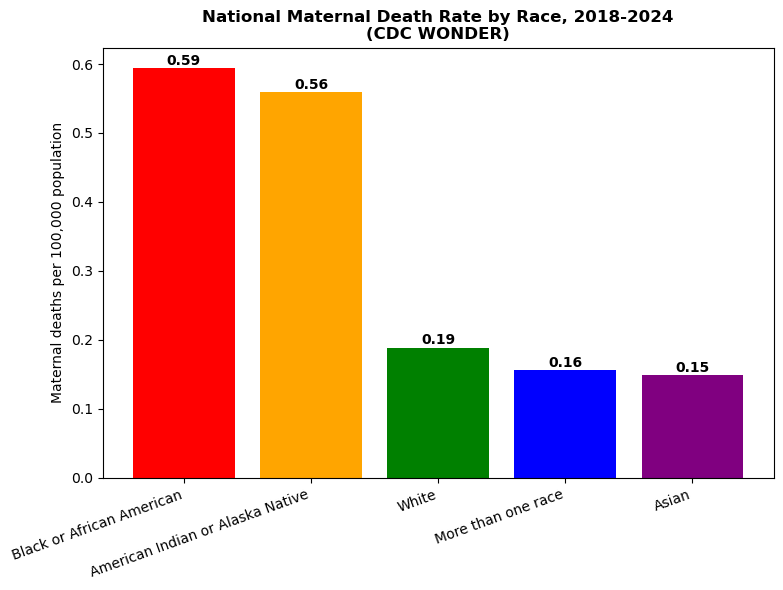

In [40]:
colors_map = {
    'Black or African American': 'red',
    'American Indian or Alaska Native': 'orange',
    'White': 'green',
    'More than one race': 'blue',
    'Asian': 'purple'
}

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(agg['race'], agg['rate_per_100k'], color=[colors_map.get(r,'gray') for r in agg['race']])

for bar, val in zip(bars, agg['rate_per_100k']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Maternal deaths per 100,000 population')
ax.set_title('National Maternal Death Rate by Race, 2018-2024\n(CDC WONDER)', fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../output/national_rate_by_race.png', dpi=150)
plt.show()

In [41]:
heatmap_data = df.pivot(index='state', columns='race', values='crude_rate')
heatmap_data.head()

race,American Indian or Alaska Native,Asian,Black or African American,More than one race,White
state,,,,,
Alabama,NaN,NaN,0.7,NaN,0.2
Alaska,NaN,NaN,NaN,NaN,0.3
Arizona,0.7,NaN,0.6,NaN,0.2
Arkansas,NaN,NaN,1.0,NaN,0.3
California,NaN,0.1,0.3,0.2,0.1


FileNotFoundError: [Errno 2] No such file or directory: '../output/state_race_heatmap.png'

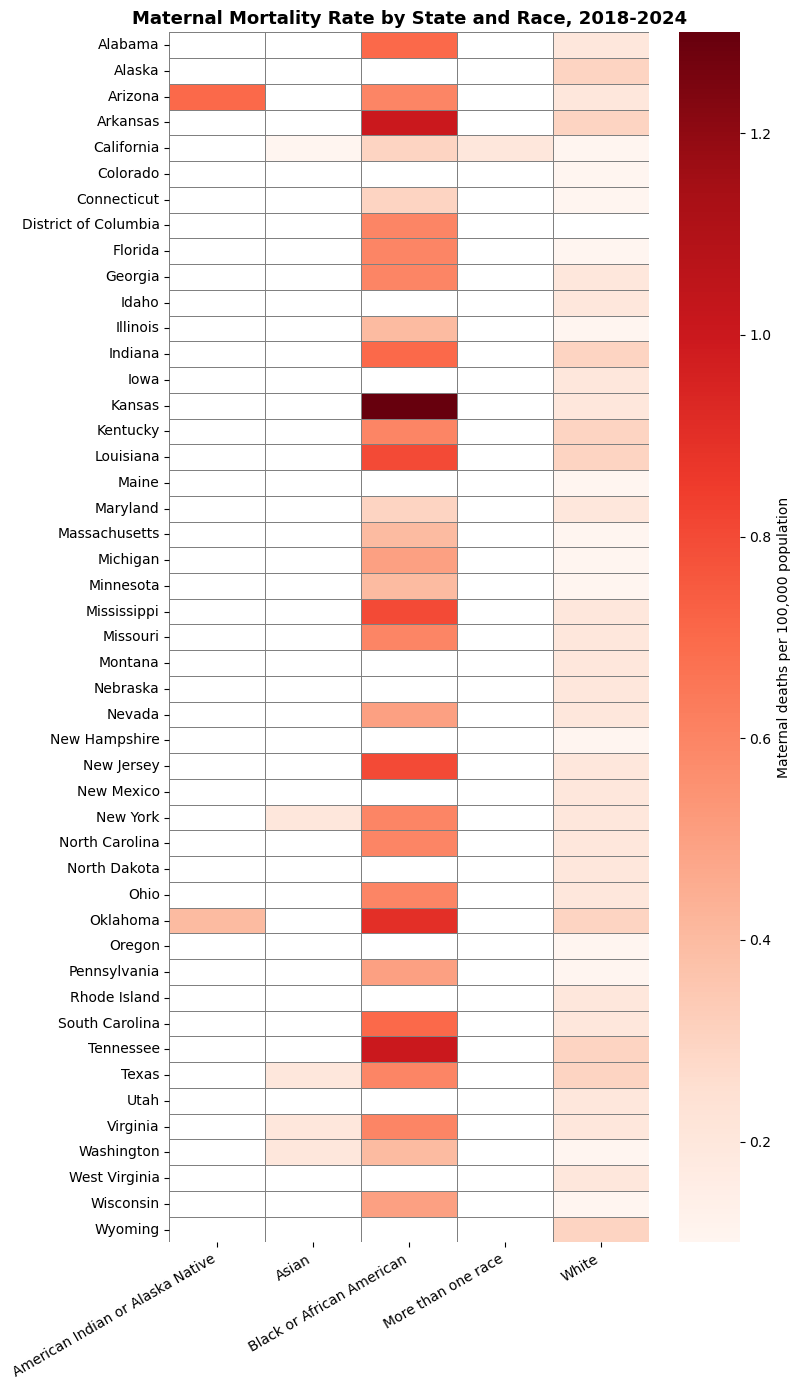

In [43]:
fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(heatmap_data, cmap='Reds', linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Maternal deaths per 100,000 population'}, ax=ax)
ax.set_title('Maternal Mortality Rate by State and Race, 2018-2024', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../output/state_race_heatmap.png', dpi=150)
plt.show()

In [11]:
ratio_data = df[df['race'].isin(['Black or African American', 'White'])].pivot(index='state', columns='race', values='crude_rate').dropna()
ratio_data.columns = ['Black', 'White']
ratio_data['ratio'] = ratio_data['Black'] / ratio_data['White']
ratio_data = ratio_data.sort_values('ratio', ascending=True)  
ratio_data.head()

,Black,White,ratio
state,,,
Maryland,0.3,0.2,1.500000
Texas,0.6,0.3,2.000000
Kentucky,0.6,0.3,2.000000
Indiana,0.7,0.3,2.333333
Nevada,0.5,0.2,2.500000


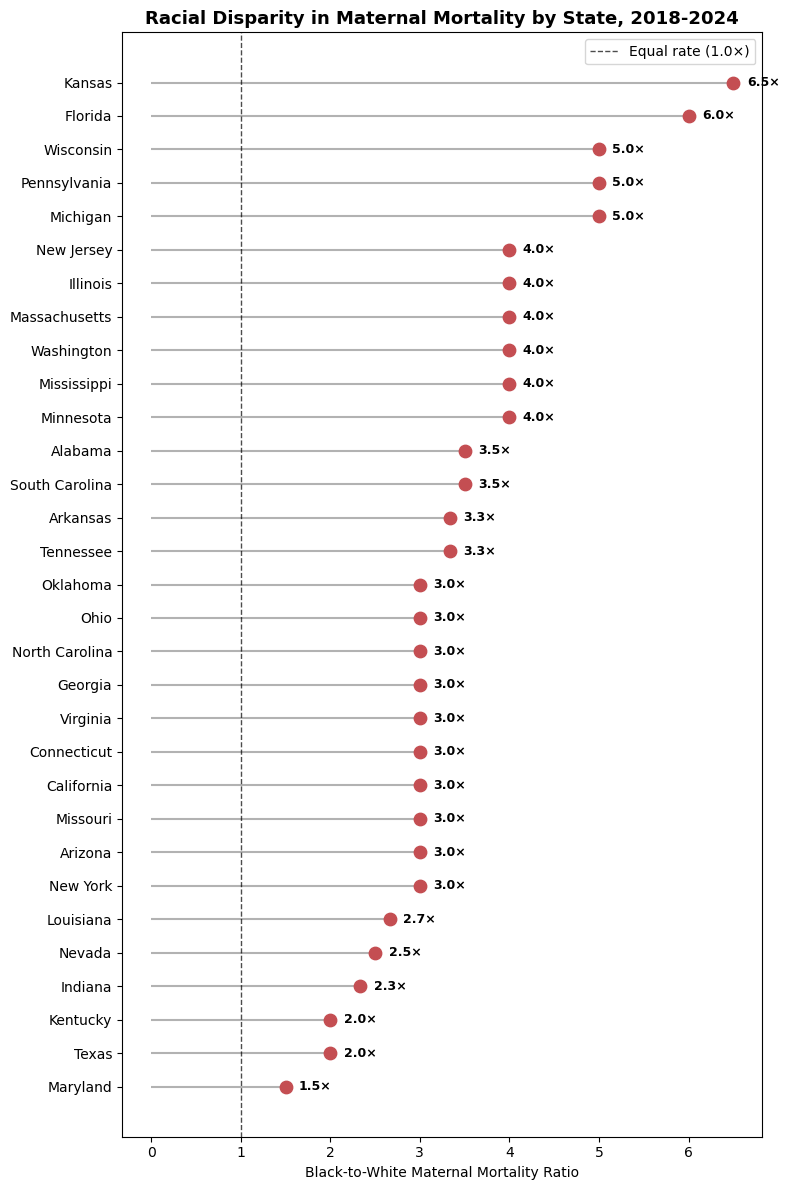

In [12]:
fig, ax = plt.subplots(figsize=(8, 12))

ax.hlines(y=ratio_data.index, xmin=0, xmax=ratio_data['ratio'], color='gray', alpha=0.6, linewidth=1.5)

ax.scatter(ratio_data['ratio'], ratio_data.index, color='#C44E52', s=80, zorder=3)

for state, ratio in zip(ratio_data.index, ratio_data['ratio']):
    ax.text(ratio + 0.15, state, f'{ratio:.1f}×', va='center', fontsize=9, fontweight='bold')

ax.axvline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Equal rate (1.0×)')
ax.set_xlabel('Black-to-White Maternal Mortality Ratio')
ax.set_title('Racial Disparity in Maternal Mortality by State, 2018-2024', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/disparity_ratio_dotplot.png', dpi=150)
plt.show()

In [14]:
overall_rate = df.groupby('state').agg(
    total_deaths=('deaths', 'sum'),
    total_population=('population', 'sum')
).reset_index()
overall_rate['overall_rate'] = overall_rate['total_deaths'] / overall_rate['total_population'] * 100000
overall_rate = overall_rate.set_index('state')['overall_rate']
overall_rate.head()

state
Alabama       0.372228
Alaska        0.301353
Arizona       0.293225
Arkansas      0.408320
California    0.118231
Name: overall_rate, dtype: float64

In [15]:
scatter_data = ratio_data.join(overall_rate)
scatter_data = scatter_data.dropna(subset=['ratio', 'overall_rate'])
scatter_data.head()

,Black,White,ratio,overall_rate
state,,,,
Maryland,0.3,0.2,1.500000,0.235345
Texas,0.6,0.3,2.000000,0.349265
Kentucky,0.6,0.3,2.000000,0.367883
Indiana,0.7,0.3,2.333333,0.353767
Nevada,0.5,0.2,2.500000,0.207166


In [16]:
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'District of Columbia': 'DC'
}

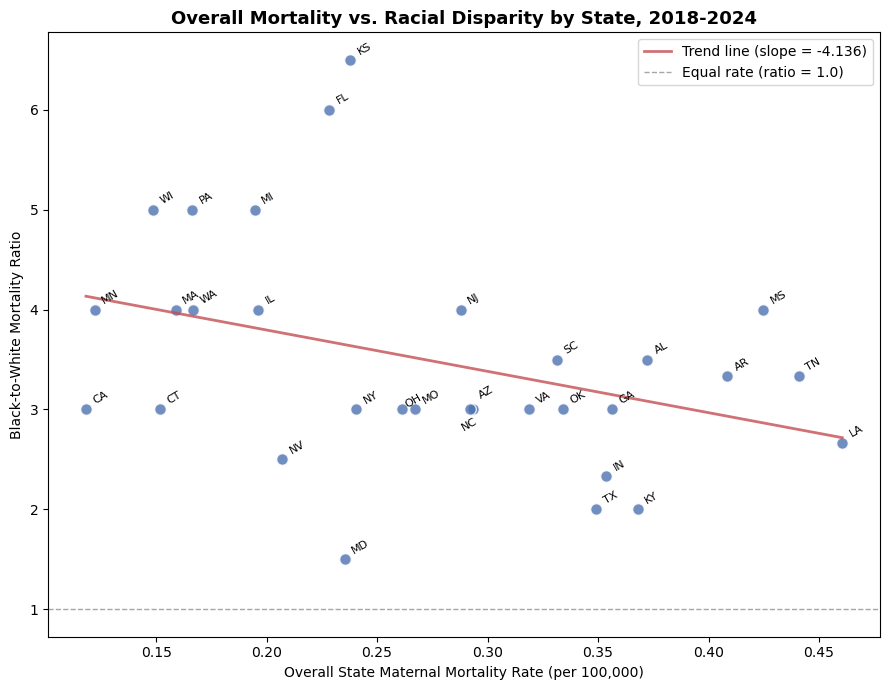

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(scatter_data['overall_rate'], scatter_data['ratio'], color='#4C72B0', s=70, alpha=0.8, edgecolor='white')

custom_offsets = {
    'AZ': (3, 8),
    'NC': (-7, -15),
    'OH': (1, 1)
} #labels don't overlap

for state, row in scatter_data.iterrows():
    label = state_abbrev.get(state, state)
    offset = custom_offsets.get(label, (4, 4))
    ax.annotate(label, (row['overall_rate'], row['ratio']), fontsize=8,
                xytext=offset, textcoords='offset points', rotation=30)
    
x = scatter_data['overall_rate']
y = scatter_data['ratio']
slope, intercept = np.polyfit(x, y, 1)
line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, color='#C44E52', linewidth=2, linestyle='-', alpha=0.8,
        label=f'Trend line (slope = {slope:.3f})')

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Equal rate (ratio = 1.0)')

ax.set_xlabel('Overall State Maternal Mortality Rate (per 100,000)')
ax.set_ylabel('Black-to-White Mortality Ratio')
ax.set_title('Overall Mortality vs. Racial Disparity by State, 2018-2024', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/overall_vs_disparity_scatter.png', dpi=150)
plt.show()

In [25]:
ratio_data_native = df[df['race'].isin(['American Indian or Alaska Native', 'White'])].pivot(
    index='state', columns='race', values='crude_rate'
).dropna()
ratio_data_native.columns = ['Native', 'White']
ratio_data_native['ratio'] = ratio_data_native['Native'] / ratio_data_native['White']
print(f"States with both Native and White rates reported: {len(ratio_data_native)}")
print(ratio_data_native.head())

scatter_data_native = ratio_data_native.join(overall_rate)
scatter_data_native = scatter_data_native.dropna(subset=['ratio', 'overall_rate'])
print(scatter_data_native.head())

States with both Native and White rates reported: 2
          Native  White     ratio
state                            
Arizona      0.7    0.2  3.500000
Oklahoma     0.4    0.3  1.333333
          Native  White     ratio  overall_rate
state                                          
Arizona      0.7    0.2  3.500000      0.293225
Oklahoma     0.4    0.3  1.333333      0.334267


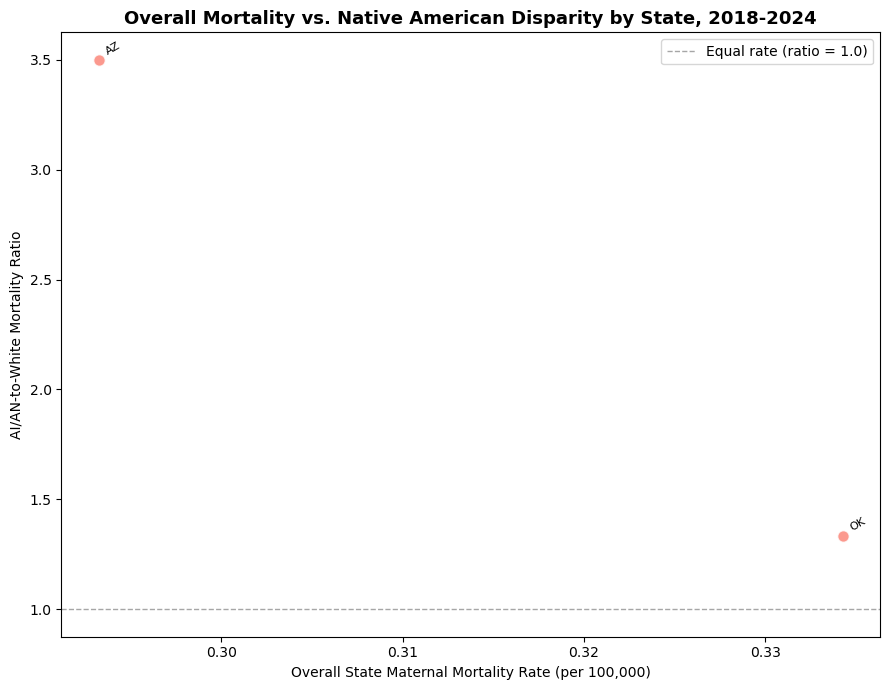

In [32]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(scatter_data_native['overall_rate'], scatter_data_native['ratio'], color='salmon', s=70, alpha=0.8, edgecolor='white')

for state, row in scatter_data_native.iterrows():
    label = state_abbrev.get(state, state)
    ax.annotate(label, (row['overall_rate'], row['ratio']), fontsize=8,
                xytext=(4, 4), textcoords='offset points', rotation=30)

if len(scatter_data_native) >= 3:
    x = scatter_data_native['overall_rate']
    y = scatter_data_native['ratio']
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, color='darkorange', linewidth=2, alpha=0.8, label=f'Trend line (slope = {slope:.3f})')

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Equal rate (ratio = 1.0)')
ax.set_xlabel('Overall State Maternal Mortality Rate (per 100,000)')
ax.set_ylabel('AI/AN-to-White Mortality Ratio')
ax.set_title('Overall Mortality vs. Native American Disparity by State, 2018-2024', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/native_vs_disparity_scatter.png', dpi=150)
plt.show()

In [31]:
ratio_data_asian = df[df['race'].isin(['Asian', 'White'])].pivot(
    index='state', columns='race', values='crude_rate'
).dropna()
ratio_data_asian.columns = ['Asian', 'White']
ratio_data_asian['ratio'] = ratio_data_asian['Asian'] / ratio_data_asian['White']
print(f"States with both Asian and White rates reported: {len(ratio_data_asian)}")
print(ratio_data_asian.head())

scatter_data_asian = ratio_data_asian.join(overall_rate)
scatter_data_asian = scatter_data_asian.dropna(subset=['ratio', 'overall_rate'])
print(scatter_data_asian.head())

States with both Asian and White rates reported: 5
            Asian  White     ratio
state                             
California    0.1    0.1  1.000000
New York      0.2    0.2  1.000000
Texas         0.2    0.3  0.666667
Virginia      0.2    0.2  1.000000
Washington    0.2    0.1  2.000000
            Asian  White     ratio  overall_rate
state                                           
California    0.1    0.1  1.000000      0.118231
New York      0.2    0.2  1.000000      0.240398
Texas         0.2    0.3  0.666667      0.349265
Virginia      0.2    0.2  1.000000      0.318735
Washington    0.2    0.1  2.000000      0.166569


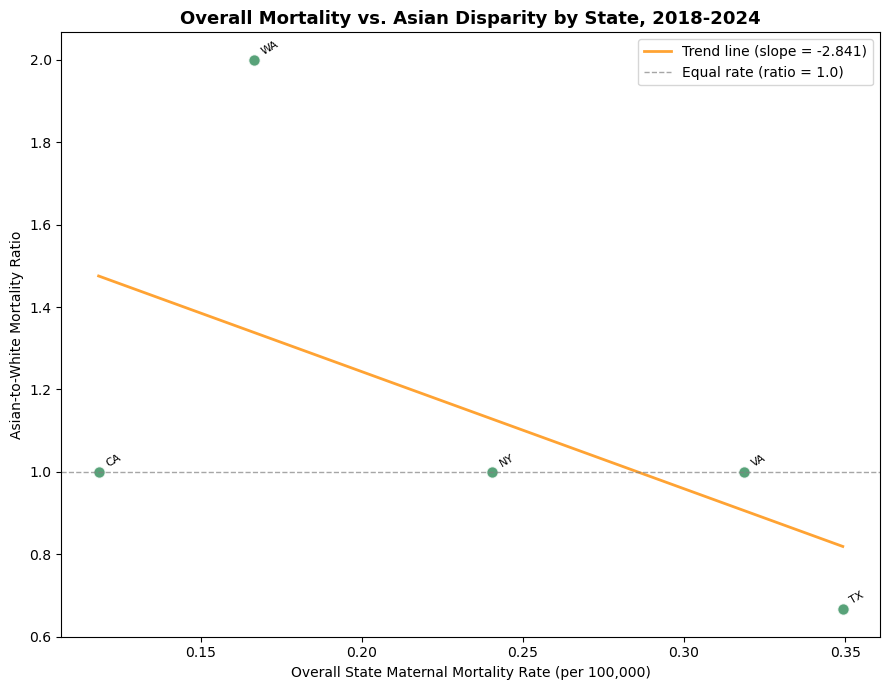

In [34]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(scatter_data_asian['overall_rate'], scatter_data_asian['ratio'], color='seagreen', s=70, alpha=0.8, edgecolor='white')

for state, row in scatter_data_asian.iterrows():
    label = state_abbrev.get(state, state)
    ax.annotate(label, (row['overall_rate'], row['ratio']), fontsize=8,
                xytext=(4, 4), textcoords='offset points', rotation=30)

if len(scatter_data_asian) >= 3:
    x = scatter_data_asian['overall_rate']
    y = scatter_data_asian['ratio']
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, color='darkorange', linewidth=2, alpha=0.8, label=f'Trend line (slope = {slope:.3f})')

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Equal rate (ratio = 1.0)')
ax.set_xlabel('Overall State Maternal Mortality Rate (per 100,000)')
ax.set_ylabel('Asian-to-White Mortality Ratio')
ax.set_title('Overall Mortality vs. Asian Disparity by State, 2018-2024', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/asian_vs_disparity_scatter.png', dpi=150)
plt.show()

In [29]:
pivot = df[df['race'].isin(['Black or African American', 'White'])].pivot(
    index='state', columns='race', values='crude_rate'
).dropna()
pivot.columns = ['Black', 'White']
pivot['ratio'] = pivot['Black'] / pivot['White']
pivot = pivot.sort_values('ratio', ascending=False)
print(f"States with both Black and White rates reported: {len(pivot)}")
pivot.head()

States with both Black and White rates reported: 31


,Black,White,ratio
state,,,
Kansas,1.3,0.2,6.5
Florida,0.6,0.1,6.0
Wisconsin,0.5,0.1,5.0
Pennsylvania,0.5,0.1,5.0
Michigan,0.5,0.1,5.0


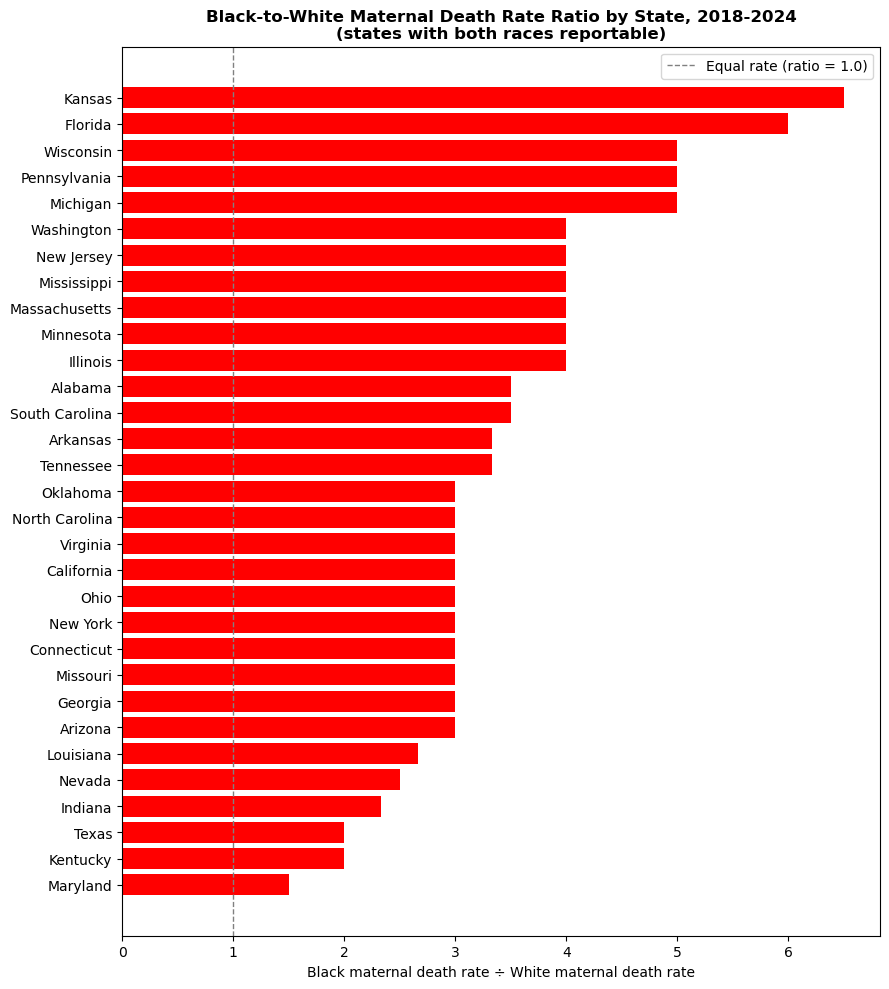

In [22]:
fig, ax = plt.subplots(figsize=(9, 10))
colors_bar = ['red' if r >= 1 else 'blue' for r in pivot['ratio']]
ax.barh(pivot.index, pivot['ratio'], color=colors_bar)
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1, label='Equal rate (ratio = 1.0)')
ax.invert_yaxis()
ax.set_xlabel('Black maternal death rate ÷ White maternal death rate')
ax.set_title('Black-to-White Maternal Death Rate Ratio by State, 2018-2024\n(states with both races reportable)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/state_black_white_ratio.png', dpi=150)
plt.show()